# Product Demand Prediction

# This project predicts **product demand (Quantity)** using the Superstore dataset.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import joblib
import os

In [26]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [27]:
# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Shape after removing duplicates: (9994, 21)


In [28]:
# Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## EDA: Quantity Distribution

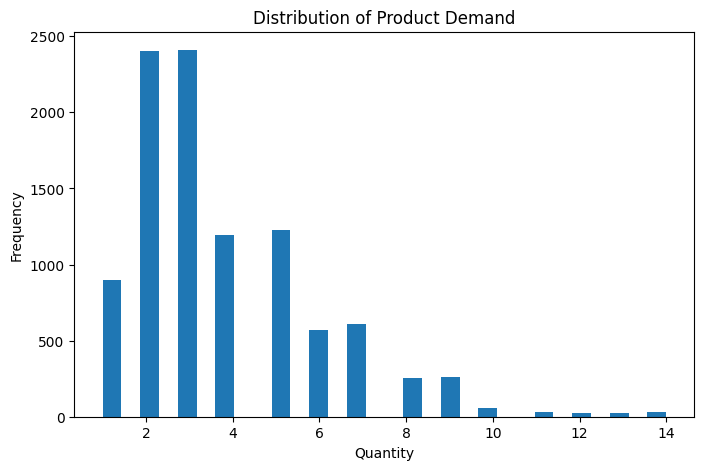

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=30)
plt.title("Distribution of Product Demand")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

## Sales vs Quantity

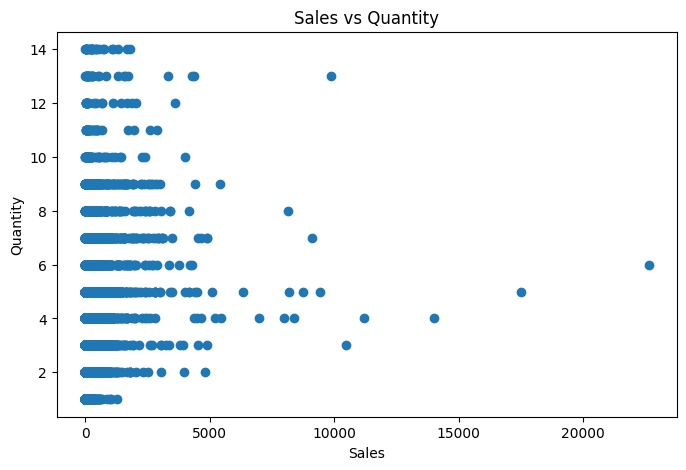

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Quantity"])
plt.xlabel("Sales")
plt.ylabel("Quantity")
plt.title("Sales vs Quantity")
plt.show()

## Discount vs Quantity

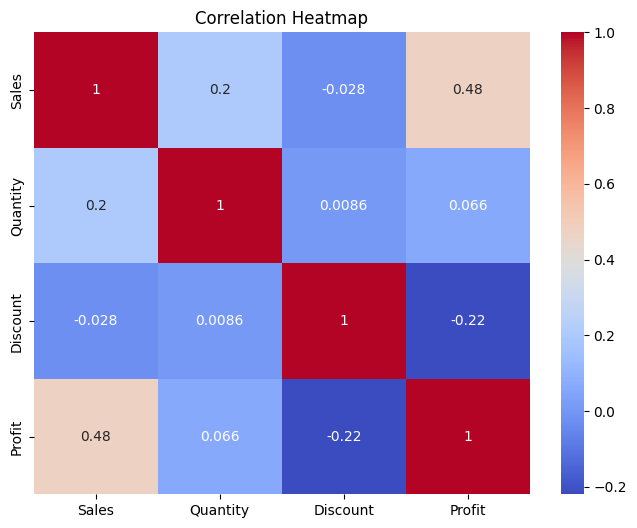

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# Create profit ratio feature
df["profit_ratio"] = df["Profit"] / df["Sales"]
df["profit_ratio"] = df["profit_ratio"].replace([np.inf, -np.inf], 0)
df["profit_ratio"] = df["profit_ratio"].fillna(0)

In [33]:
features = [
    "Sales",
    "Discount",
    "Profit",
    "profit_ratio"
]

df_model = df[features + ["Quantity"]]

df_model.head()

,Sales,Discount,Profit,profit_ratio,Quantity
0,261.9600,0.00,41.9136,0.1600,2
1,731.9400,0.00,219.5820,0.3000,3
2,14.6200,0.00,6.8714,0.4700,2
3,957.5775,0.45,-383.0310,-0.4000,5
4,22.3680,0.20,2.5164,0.1125,2


In [34]:
X = df_model[features]
y = df_model["Quantity"]

print("Feature Shape:", X.shape)

Feature Shape: (9994, 4)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [41]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [42]:
# Linear Regression
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

# Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

In [43]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, rf_mae, gb_mae],
    "MSE": [lr_mse, rf_mse, gb_mse],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse],
    "R2 Score": [lr_r2, rf_r2, gb_r2]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.708796,5.053367,2.247970,-0.003990
1,Random Forest,1.306265,3.771465,1.942026,0.250695
2,Gradient Boosting,1.508225,3.977957,1.994482,0.209669


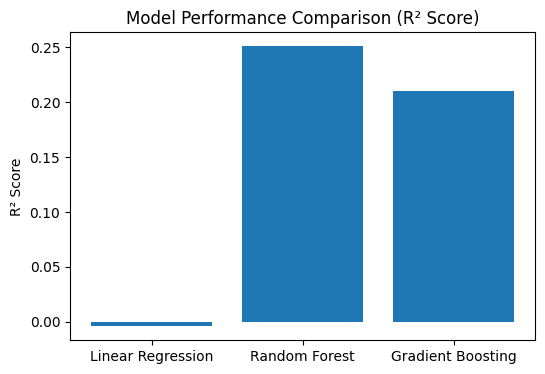

In [44]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Performance Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

In [45]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

scores = {
    "Linear Regression": lr_r2,
    "Random Forest": rf_r2,
    "Gradient Boosting": gb_r2
}

best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


        Feature  Importance
0         Sales    0.485261
2        Profit    0.330120
3  profit_ratio    0.145569
1      Discount    0.039050


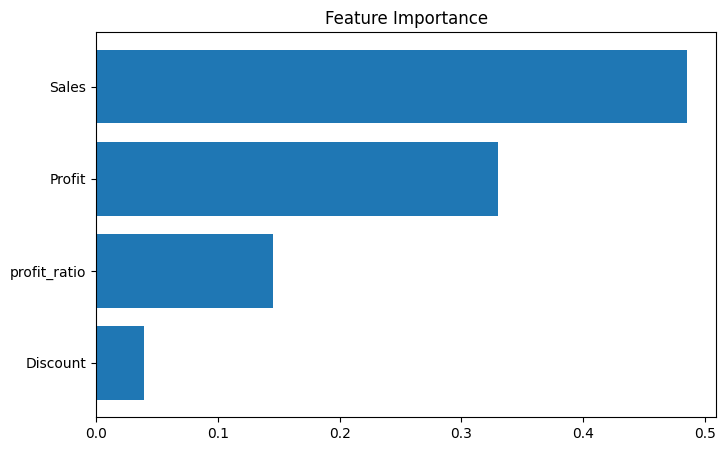

In [46]:
importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [47]:
joblib.dump(best_model, "model.pkl")

print("Model saved as model.pkl")

Model saved as model.pkl
